In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
from clean_data import adf_columns
import datetime as dt
from numpy.linalg import svd
import pprint
import numerika.numerical as numerical
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [ ]:
df = pd.read_csv("data/electricity_dah_prices.csv")

In [ ]:
df[df["france"].isna()]

,date,hour,france,italy,belgium,spain,uk,germany
2042,2022/03/27,02:00 - 03:00,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_clean = pd.read_csv("data/clean_france.csv", index_col="date")

In [ ]:
df_clean.index = pd.to_datetime(df_clean.index, format="%m/%d/%Y")
df_clean["day"] = df_clean.index.map(dt.date.weekday)
df_clean = df_clean[df_clean["day"] <= 4]
df_clean = df_clean.drop(columns="day")

In [ ]:
df_clean[df_clean["8"]>1500]

,1,2,3,4,5,6,7,8,9,10,...,15,16,17,18,19,20,21,22,23,24
date,,,,,,,,,,,,,,,,,,,,,
2022-04-04,329.09,310.0,329.09,329.07,328.97,413.32,410.13,2712.99,2987.78,478.81,...,293.59,286.9,267.81,276.98,319.63,372.01,378.9,345.27,341.1,325.33


In [ ]:
summary_statistics = df_clean.describe().round(1).iloc[1:,[2,8,14,20]]
summary_statistics.to_latex("visual/before_summary_stats")

In [ ]:
df_clean.loc["2022-04-04",["8","9"]] = np.nan
df_clean = df_clean.interpolate("linear", axis=1)

<Axes: xlabel='date'>

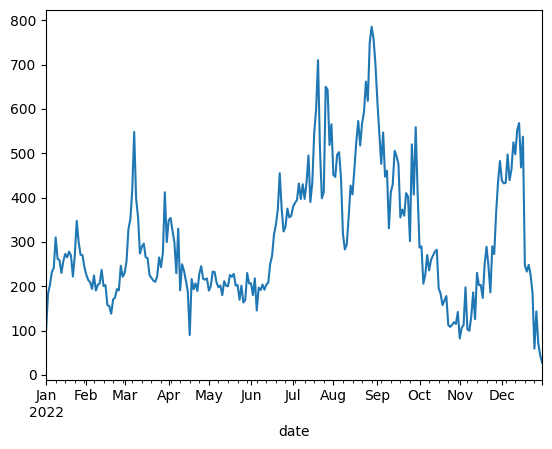

In [ ]:
df_clean.iloc[:,11].T.plot(legend=False)

In [ ]:
adf_columns(df_clean)

Prices in 18:00 are stationary throughout the year.


In [ ]:
df_difference = df_clean - df_clean.shift(1)

<Axes: xlabel='date'>

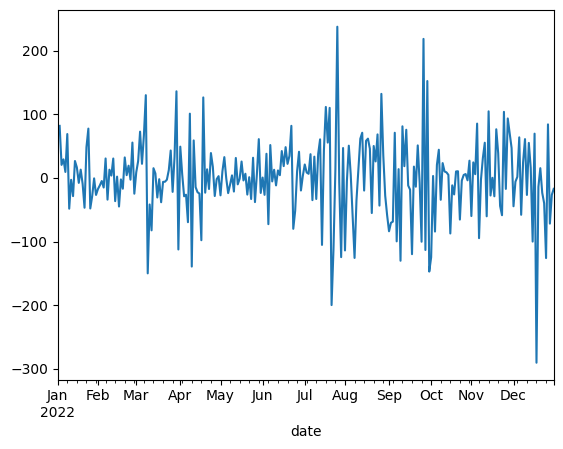

In [ ]:
df_difference["12"].round(2).plot(legend=False)

<Axes: >

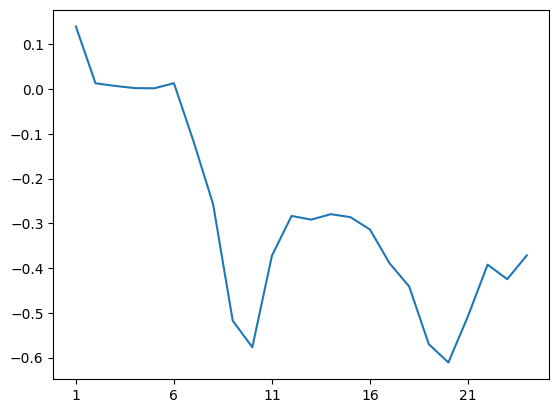

In [ ]:
df_difference.mean().plot()

In [ ]:
df_demeaned = df_difference.copy()
for col in df_difference:
    df_demeaned[col] = df_demeaned[col] - df_demeaned[col].mean()
df_demeaned = df_demeaned.round(2).dropna()

<Axes: xlabel='date'>

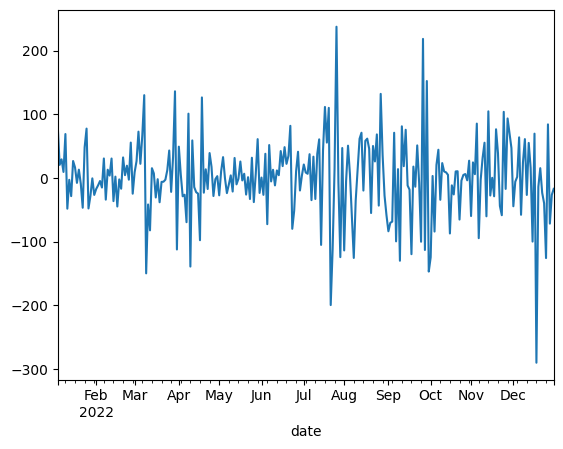

In [ ]:
df_demeaned["12"].plot()

In [ ]:
(df_demeaned.iloc[:,2::6].describe()[1:]).to_latex("visual/after_summary_stats")

In [ ]:
df_demeaned[df_demeaned["8"] < 1000].describe()

,1,2,3,4,5,6,7,8,9,10,...,15,16,17,18,19,20,21,22,23,24
count,2.590000e+02,259.000000,259.000000,259.000000,259.000000,259.000000,259.000000,259.000000,259.000000,259.000000,...,259.000000,259.000000,259.000000,259.000000,259.000000,259.000000,259.000000,259.000000,259.000000,259.000000
mean,-8.778906e-16,0.003050,-0.002857,0.002278,0.001853,0.003282,0.003475,0.002625,0.002394,0.003127,...,0.003938,-0.003784,0.000811,-0.001004,0.000039,-0.000888,0.002548,-0.002239,-0.004710,-0.001622
std,5.192870e+01,54.632437,50.436877,51.738432,50.393295,47.186417,49.809693,60.126738,67.595132,72.607283,...,61.632564,63.655827,58.286849,55.935277,58.391013,66.454070,54.449006,51.593705,43.268271,49.986254
min,-2.532200e+02,-291.310000,-194.810000,-192.590000,-200.400000,-180.900000,-160.470000,-213.780000,-292.640000,-310.040000,...,-337.420000,-301.810000,-247.690000,-251.130000,-229.280000,-263.280000,-191.000000,-315.270000,-195.280000,-218.370000
25%,-2.149000e+01,-21.000000,-18.220000,-17.995000,-17.095000,-18.120000,-23.455000,-27.615000,-28.950000,-29.640000,...,-27.915000,-25.035000,-26.195000,-28.145000,-28.500000,-27.560000,-24.710000,-19.275000,-19.445000,-21.285000
50%,1.160000e+00,1.610000,1.060000,2.090000,3.590000,-1.750000,3.090000,0.830000,0.600000,1.370000,...,2.170000,-0.290000,0.160000,1.380000,-1.180000,-3.780000,-0.350000,-0.920000,1.420000,3.900000
75%,2.642500e+01,27.320000,23.450000,22.685000,24.970000,25.180000,25.670000,26.760000,30.140000,36.300000,...,30.855000,31.285000,30.365000,31.700000,34.565000,29.835000,21.990000,23.705000,20.060000,23.450000
max,2.500600e+02,259.490000,248.060000,227.670000,126.520000,155.080000,150.450000,179.160000,266.060000,344.040000,...,268.480000,299.200000,163.040000,158.890000,226.190000,262.090000,249.330000,222.120000,151.430000,187.410000


In [ ]:
df_demeaned.to_csv("/home/hbrvk/projects/svd_energy/numerika/data.csv")

In [ ]:
U, singular_values ,Vt = svd(df_demeaned)
Vt = pd.DataFrame(Vt)

<Axes: >

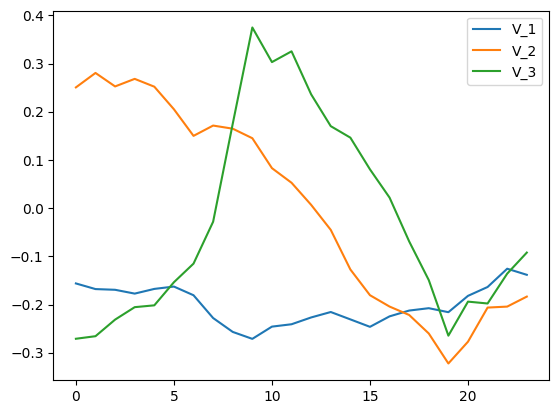

In [ ]:
Vt = pd.DataFrame(Vt)
Vt.index = [f"V_{i}" for i in range(1,25)]
Vt.iloc[:3,:].T.plot()

<Axes: >

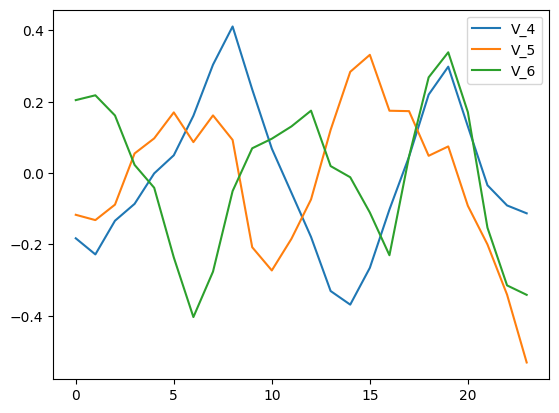

In [ ]:
Vt.iloc[3:6,:].T.plot()

In [ ]:
pprint.pprint(singular_values.round(1))

array([3486.7, 1641.5, 1215.1,  988.1,  762.2,  602.7,  541.4,  509.3,
        463. ,  441.6,  390.2,  362.4,  339.3,  318. ,  273.8,  259.1,
        253.5,  228.7,  207. ,  198.1,  197.3,  173. ,  154.1,  125. ])


In [ ]:
singular_values = pd.Series(singular_values.round(1))
x = np.square(singular_values) / sum(np.square(singular_values))
var_series = pd.Series([sum(x[:i]) for i in range(1, len(singular_values) + 1)]).round(3)
singular_table = pd.concat([singular_values, var_series], axis=1)
singular_table.columns = ["singular", "var"]

In [ ]:
sum(x[:3])

0.8099517238961089

In [ ]:
singular_table[:6].to_latex("visual/singular")

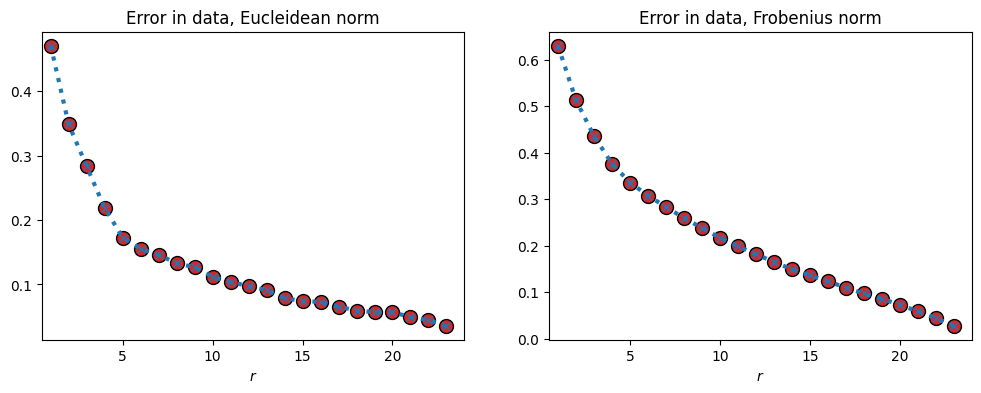

In [ ]:
VyvojRelChyby_2 = np.zeros(df_demeaned.shape[1]-1); VyvojRelChyby_F = np.zeros_like(VyvojRelChyby_2)
PredikceRelChyby_2 = np.zeros_like(VyvojRelChyby_2); PredikceRelChyby_F = np.zeros_like(VyvojRelChyby_F)

r_totry = np.arange(1,df_demeaned.shape[1],1)
u,s,vt = np.linalg.svd(df_demeaned);

norm_2_data = np.linalg.norm(df_demeaned, ord=2)
norm_F_data = np.linalg.norm(df_demeaned, ord='fro')
jmenovatel_F_theory = np.sqrt(np.sum(s**2))

for i in range(1, 24):
    A_r = u[:, :i] @ np.diag(s[:i]) @ vt[:i, :]
    
    VyvojRelChyby_2[i-1] = np.linalg.norm(df_demeaned - A_r, ord=2) / norm_2_data
    VyvojRelChyby_F[i-1] = np.linalg.norm(df_demeaned - A_r, ord='fro') / norm_F_data
    
    PredikceRelChyby_2[i-1] = s[i] / s[0]
    PredikceRelChyby_F[i-1] = np.sqrt(np.sum(s[i:]**2)) / jmenovatel_F_theory

fig = plt.figure(figsize=(12,4)); ranks = np.arange(1,df_demeaned.shape[1],1);
ax = plt.subplot(1,2,1)
ax.plot(ranks,VyvojRelChyby_2, 'o', ms=10, color="tab:red", markeredgecolor="k")
ax.plot(ranks,PredikceRelChyby_2, 'x:', color="tab:blue", lw=3)
ax.set_xlabel(r"$r$"); ax.set_xlim([0.5,24]); plt.title('Error in data, Eucleidean norm');
ax = plt.subplot(1,2,2)
ax.plot(ranks,VyvojRelChyby_F, 'o', ms=10, color="tab:red", markeredgecolor="k")
ax.plot(ranks,PredikceRelChyby_F, 'x:', color="tab:blue", lw=3)
ax.set_xlabel(r"$r$"); ax.set_xlim([0.5,24]); plt.title('Error in data, Frobenius norm');
plt.show()

In [ ]:
plt.close("all")

In [ ]:
hours = np.arange(24)
mu = 12
sigma = 2.5
max_mw = 50
x = np.exp(-0.5 * ((hours - mu) / sigma)**2)
x = x * max_mw
x[x < 0.5] = 0
print(np.round(x, 1))

[ 0.   0.   0.   0.   0.   1.   2.8  6.8 13.9 24.3 36.3 46.2 50.  46.2
 36.3 24.3 13.9  6.8  2.8  1.   0.   0.   0.   0. ]


In [ ]:
model = sm.OLS(x,Vt.iloc[:6,:].T)
res = model.fit()
print(res.summary())

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.943
Model:                            OLS   Adj. R-squared (uncentered):              0.923
Method:                 Least Squares   F-statistic:                              49.22
Date:                Thu, 26 Mar 2026   Prob (F-statistic):                    3.37e-10
Time:                        20:00:27   Log-Likelihood:                         -73.388
No. Observations:                  24   AIC:                                      158.8
Df Residuals:                      18   BIC:                                      165.8
Df Model:                           6                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------